# 42 — SMOTE / ADASYN Oversampling for the Cliff (Active) Region

The PXR training set is heavily class-imbalanced: only ~1.6% of compounds have pEC50 ≥ 6
(hits). SMOTE-style oversampling synthesises new training examples in the minority (active)
region so LGBM can better learn that part of the response surface.

**Key design choices:**
- Discretise pEC50 into 3 classes *only* for SMOTE sampling; regress on the original
  continuous pEC50 for the actual LGBM fit.
- Synthetic sample pEC50 values are interpolated from the k nearest neighbours' actual
  pEC50 values (not the discrete class label).
- SMOTE is fit *only on the fold-train* — never on validation data.

Methods compared: RandomOverSampler, SMOTE, ADASYN, BorderlineSMOTE.

In [1]:
import sys, os, warnings
os.environ["PYTHONIOENCODING"] = "utf-8"
try:
    sys.stdout.reconfigure(encoding="utf-8")
except AttributeError:
    pass
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

from pxr.data import load_train, load_test
from pxr.featurize import combined, impute
from pxr.eval import rae, scaffold_kfold_indices, compute_metrics
from pxr.chem import bemis_murcko
from pxr.paths import DATA_PROCESSED, SUBMISSIONS

# Check imbalanced-learn availability
try:
    from imblearn.over_sampling import (
        RandomOverSampler, SMOTE, ADASYN, BorderlineSMOTE)
    IMBLEARN_AVAILABLE = True
    print('imbalanced-learn available')
except ImportError:
    IMBLEARN_AVAILABLE = False
    print('imbalanced-learn not available. '
          'Install with: pip install imbalanced-learn')
    print('Will proceed with manual RandomOverSampler fallback only.')

LGBM_PARAMS = dict(
    n_estimators=1000, num_leaves=64, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=0.1,
    min_child_samples=10, n_jobs=4, verbose=-1
)

SEED = 42
print('Setup complete')

imbalanced-learn available
Setup complete


## 1. Load data + setup

In [2]:
tr = load_train()
te = load_test()
print(f'Train: {len(tr):,}  Test: {len(te):,}')

print('Featurizing...')
X_tr = impute(combined(tr['smiles'].tolist()))
X_te = impute(combined(te['smiles'].tolist()))
y_tr = tr['pec50'].values.astype(np.float32)

print(f'X_tr: {X_tr.shape}  y_tr: {y_tr.shape}')
print(f'pEC50 distribution: min={y_tr.min():.2f}  median={np.median(y_tr):.2f}  max={y_tr.max():.2f}')
print(f'Active compounds (pEC50 >= 6): {(y_tr >= 6).sum()} ({100*(y_tr >= 6).mean():.1f}%)')

scaffolds = tr['smiles'].map(bemis_murcko).tolist()
splits = scaffold_kfold_indices(scaffolds, n_splits=5, seed=SEED)

Train: 4,139  Test: 513
Featurizing...


X_tr: (4139, 2265)  y_tr: (4139,)
pEC50 distribution: min=1.61  median=4.65  max=7.55
Active compounds (pEC50 >= 6): 67 (1.6%)


## 2. Define cliff region + discretization for SMOTE

In [3]:
def discretize_pec50(y_cont):
    """Map continuous pEC50 to 3 classes for SMOTE definition.

    Class 0: inactive  (pEC50 < 5.0)
    Class 1: moderate  (5.0 <= pEC50 < 6.0)
    Class 2: active    (pEC50 >= 6.0)  <- minority class

    Used ONLY to drive SMOTE sampling strategy.
    The regressor always trains on the original continuous y.
    """
    y_disc = np.zeros(len(y_cont), dtype=int)
    y_disc[(y_cont >= 5.0) & (y_cont < 6.0)] = 1
    y_disc[y_cont >= 6.0] = 2
    return y_disc

y_disc_all = discretize_pec50(y_tr)
print('Class distribution:')
for c, name in [(0, 'inactive (<5)'), (1, 'moderate (5-6)'), (2, 'active (>=6)')]:
    n = (y_disc_all == c).sum()
    print(f'  Class {c} ({name:16s}): {n:,} ({100*n/len(y_disc_all):.1f}%)')

def interpolate_y_for_synthetic(X_synth, X_orig, y_orig, k=5):
    """For each synthetic sample, find k nearest original neighbours (L2 in feature space)
    and interpolate their pEC50 values by inverse-distance weighting.

    This ensures synthetic samples have realistic continuous pEC50 values.
    """
    from sklearn.neighbors import NearestNeighbors
    nn = NearestNeighbors(n_neighbors=k, n_jobs=4)
    nn.fit(X_orig)
    dists, idxs = nn.kneighbors(X_synth)
    # Inverse-distance weighting (add small epsilon to avoid division by zero)
    weights = 1.0 / (dists + 1e-6)
    weights /= weights.sum(axis=1, keepdims=True)
    y_synth = (weights * y_orig[idxs]).sum(axis=1)
    return y_synth.astype(np.float32)

print('\nDiscretization and interpolation helpers defined.')

Class distribution:
  Class 0 (inactive (<5)   ): 2,803 (67.7%)
  Class 1 (moderate (5-6)  ): 1,269 (30.7%)
  Class 2 (active (>=6)    ): 67 (1.6%)

Discretization and interpolation helpers defined.


## 3. SMOTE variants definition

In [4]:
if IMBLEARN_AVAILABLE:
    # Sampling strategy: oversample class 2 (active) to 10% of dataset size
    def get_sampling_strategy(y_disc, target_frac=0.10):
        """Compute how many samples of class 2 we need to reach target_frac of dataset."""
        n_total = len(y_disc)
        n_other = (y_disc != 2).sum()
        n_target = int(n_other * target_frac / (1 - target_frac))
        n_current = (y_disc == 2).sum()
        if n_target <= n_current:
            return 'auto'  # already enough
        return {2: n_target}  # class 2: active

    SAMPLERS = {
        'RandomOverSampler': lambda strat: RandomOverSampler(
            sampling_strategy=strat, random_state=SEED),
        'SMOTE': lambda strat: SMOTE(
            sampling_strategy=strat, k_neighbors=5, random_state=SEED),
        'ADASYN': lambda strat: ADASYN(
            sampling_strategy=strat, n_neighbors=5, random_state=SEED),
        'BorderlineSMOTE': lambda strat: BorderlineSMOTE(
            sampling_strategy=strat, k_neighbors=5, random_state=SEED,
            kind='borderline-1'),
    }
else:
    # Manual RandomOverSampler fallback
    class ManualRandomOverSampler:
        def __init__(self, target_frac=0.10, random_state=42):
            self.target_frac = target_frac
            self.rng = np.random.default_rng(random_state)

        def fit_resample(self, X, y_disc, y_cont=None):
            minority_idx = np.where(y_disc == 2)[0]
            n_current = len(minority_idx)
            n_other = (y_disc != 2).sum()
            n_target = int(n_other * self.target_frac / (1 - self.target_frac))
            if n_target <= n_current:
                return X, y_disc, y_cont
            extra = self.rng.choice(minority_idx, size=n_target - n_current, replace=True)
            X_new = np.vstack([X, X[extra]])
            y_disc_new = np.concatenate([y_disc, y_disc[extra]])
            if y_cont is not None:
                y_cont_new = np.concatenate([y_cont, y_cont[extra]])
                return X_new, y_disc_new, y_cont_new
            return X_new, y_disc_new

    SAMPLERS = {
        'ManualRandomOverSampler': lambda strat: ManualRandomOverSampler(
            target_frac=0.10, random_state=SEED)
    }

print(f'Samplers available: {list(SAMPLERS.keys())}')

Samplers available: ['RandomOverSampler', 'SMOTE', 'ADASYN', 'BorderlineSMOTE']


## 4. Scaffold 5-fold CV with each sampling strategy

In [5]:
# First run baseline (no oversampling)
print('=== Baseline (no oversampling) ===')
oof_baseline = np.full(len(y_tr), np.nan)
for fold, (tr_idx, va_idx) in enumerate(splits):
    m = lgb.LGBMRegressor(**LGBM_PARAMS)
    m.fit(X_tr[tr_idx], y_tr[tr_idx],
          callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
          eval_set=[(X_tr[va_idx], y_tr[va_idx])])
    oof_baseline[va_idx] = m.predict(X_tr[va_idx])

rae_baseline = rae(y_tr, oof_baseline)
active_mask_all = y_tr >= 5.5
rae_baseline_active = rae(y_tr[active_mask_all], oof_baseline[active_mask_all])
print(f'Baseline OOF RAE (overall): {rae_baseline:.4f}')
print(f'Baseline OOF RAE (pEC50 >= 5.5): {rae_baseline_active:.4f}  (n={active_mask_all.sum()})')

=== Baseline (no oversampling) ===


Baseline OOF RAE (overall): 0.5599
Baseline OOF RAE (pEC50 >= 5.5): 3.6854  (n=380)


In [6]:
results = {}
oof_arrays = {'Baseline (no oversampling)': oof_baseline}

for sampler_name, sampler_factory in SAMPLERS.items():
    print(f'\n=== {sampler_name} ===')
    oof = np.full(len(y_tr), np.nan)

    for fold, (tr_idx, va_idx) in enumerate(splits):
        X_fold_tr = X_tr[tr_idx]
        y_fold_tr = y_tr[tr_idx]
        y_disc_fold = discretize_pec50(y_fold_tr)

        # Fit SMOTE on fold-train ONLY
        try:
            strat = get_sampling_strategy(y_disc_fold) if IMBLEARN_AVAILABLE else 'auto'
            sampler = sampler_factory(strat)

            if IMBLEARN_AVAILABLE:
                # Resample in feature space; y returned as discrete class
                X_res, y_disc_res = sampler.fit_resample(X_fold_tr, y_disc_fold)
                n_orig = len(X_fold_tr)
                n_synth = len(X_res) - n_orig

                # For original samples: keep original pEC50
                # For synthetic samples: interpolate from k nearest original neighbours
                if n_synth > 0:
                    X_synth = X_res[n_orig:]
                    y_synth = interpolate_y_for_synthetic(
                        X_synth, X_fold_tr, y_fold_tr, k=5)
                    y_res = np.concatenate([y_fold_tr, y_synth])
                else:
                    y_res = y_fold_tr
            else:
                # Manual oversampler returns continuous y directly
                X_res, y_disc_res, y_res = sampler.fit_resample(
                    X_fold_tr, y_disc_fold, y_fold_tr)
                n_synth = len(X_res) - len(X_fold_tr)

            print(f'  Fold {fold}: {len(X_fold_tr):,} -> {len(X_res):,} '
                  f'(+{n_synth} synthetic; '
                  f'active frac: {(y_disc_res==2).mean():.1%})')

        except Exception as exc:
            print(f'  Fold {fold}: sampling failed ({exc}). Using original data.')
            X_res = X_fold_tr
            y_res = y_fold_tr

        m = lgb.LGBMRegressor(**LGBM_PARAMS)
        m.fit(X_res, y_res,
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
              eval_set=[(X_tr[va_idx], y_tr[va_idx])])
        oof[va_idx] = m.predict(X_tr[va_idx])

    rae_overall = rae(y_tr, oof)
    rae_active  = rae(y_tr[active_mask_all], oof[active_mask_all])
    results[sampler_name] = {'RAE_overall': rae_overall, 'RAE_active': rae_active}
    oof_arrays[sampler_name] = oof
    print(f'  OOF RAE overall: {rae_overall:.4f}  (vs baseline {rae_baseline:.4f})')
    print(f'  OOF RAE active (>=5.5): {rae_active:.4f}  (vs baseline {rae_baseline_active:.4f})')


=== RandomOverSampler ===


  Fold 0: 3,311 -> 3,614 (+303 synthetic; active frac: 10.0%)


  Fold 1: 3,311 -> 3,621 (+310 synthetic; active frac: 10.0%)


  Fold 2: 3,311 -> 3,615 (+304 synthetic; active frac: 10.0%)


  Fold 3: 3,311 -> 3,620 (+309 synthetic; active frac: 10.0%)


...

  Fold 1: 3,311 -> 3,621 (+310 synthetic; active frac: 10.0%)


  Fold 2: 3,311 -> 3,615 (+304 synthetic; active frac: 10.0%)


  Fold 3: 3,311 -> 3,620 (+309 synthetic; active frac: 10.0%)


  Fold 4: 3,312 -> 3,626 (+314 synthetic; active frac: 10.0%)


  OOF RAE overall: 0.5613  (vs baseline 0.5599)
  OOF RAE active (>=5.5): 3.7112  (vs baseline 3.6854)



Comparison:
                   Sampler  RAE_overall  RAE_active
                    ADASYN       0.5578      3.7678
Baseline (no oversampling)       0.5599      3.6854
                     SMOTE       0.5613      3.7732
           BorderlineSMOTE       0.5613      3.7112
         RandomOverSampler       0.5619      3.5559


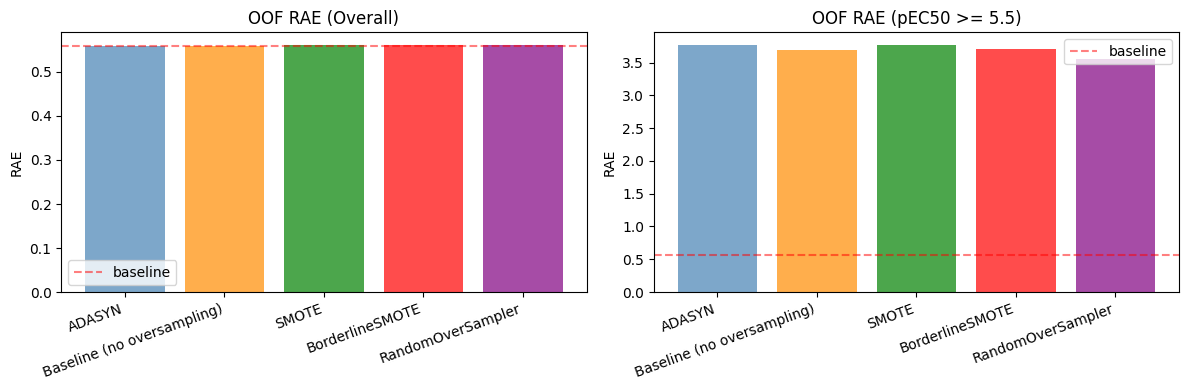

In [7]:
# ── Summary table ──────────────────────────────────────────────────────────
results['Baseline (no oversampling)'] = {
    'RAE_overall': rae_baseline, 'RAE_active': rae_baseline_active}

results_df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Sampler'})
results_df = results_df.sort_values('RAE_overall')
print('\nComparison:')
print(results_df.to_string(index=False, float_format='{:.4f}'.format))

# Bar plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['steelblue', 'darkorange', 'green', 'red', 'purple']
for ax, col, title in [
    (axes[0], 'RAE_overall', 'OOF RAE (Overall)'),
    (axes[1], 'RAE_active', 'OOF RAE (pEC50 >= 5.5)'),
]:
    ax.bar(range(len(results_df)), results_df[col],
           color=colors[:len(results_df)], alpha=0.7)
    ax.set_xticks(range(len(results_df)))
    ax.set_xticklabels(results_df['Sampler'], rotation=20, ha='right')
    ax.set_ylabel('RAE'); ax.set_title(title)
    ax.axhline(rae_baseline, color='red', linestyle='--', alpha=0.5, label='baseline')
    ax.legend()
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'figures' / '42_smote_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

## 5. Best strategy — final model + save

In [8]:
# Identify best sampler by overall OOF RAE
best_sampler_name = results_df.iloc[0]['Sampler']
best_rae = results_df.iloc[0]['RAE_overall']
print(f'Best sampler: {best_sampler_name}  OOF RAE={best_rae:.4f}')

oof_best = oof_arrays[best_sampler_name]
np.save(DATA_PROCESSED / 'oof_smote_best.npy', oof_best)
print('Saved oof_smote_best.npy')

# ── Train final model on all data with best sampler ───────────────────────
print('Training final model on all training data...')
y_disc_all = discretize_pec50(y_tr)

if best_sampler_name == 'Baseline (no oversampling)':
    X_final = X_tr
    y_final = y_tr
else:
    try:
        strat = get_sampling_strategy(y_disc_all) if IMBLEARN_AVAILABLE else 'auto'
        sampler_final = SAMPLERS[best_sampler_name](strat)
        if IMBLEARN_AVAILABLE:
            X_res_full, _ = sampler_final.fit_resample(X_tr, y_disc_all)
            n_orig = len(X_tr)
            n_synth = len(X_res_full) - n_orig
            if n_synth > 0:
                y_synth_full = interpolate_y_for_synthetic(X_res_full[n_orig:], X_tr, y_tr)
                y_res_full = np.concatenate([y_tr, y_synth_full])
            else:
                y_res_full = y_tr
            X_final = X_res_full
            y_final = y_res_full
        else:
            X_final, _, y_final = sampler_final.fit_resample(X_tr, y_disc_all, y_tr)
        print(f'  Resampled: {len(X_tr):,} -> {len(X_final):,}')
    except Exception as exc:
        print(f'Final resampling failed ({exc}). Using original data.')
        X_final = X_tr
        y_final = y_tr

final_model = lgb.LGBMRegressor(**LGBM_PARAMS)
final_model.fit(X_final, y_final, callbacks=[lgb.log_evaluation(-1)])
te_preds = final_model.predict(X_te)

lo_clip = float(y_tr.min()) - 0.5
hi_clip = float(y_tr.max()) + 0.5
te_preds = np.clip(te_preds, lo_clip, hi_clip)

print(f'Test predictions — min={te_preds.min():.2f}  '
      f'median={np.median(te_preds):.2f}  max={te_preds.max():.2f}')

sub = pd.DataFrame({
    'Molecule Name': te['name'].values,
    'pEC50': te_preds,
})
assert len(sub) == 513 and sub['pEC50'].notna().all()
out_path = SUBMISSIONS / '42_smote_adasyn.csv'
sub.to_csv(out_path, index=False)
print(f'Saved: {out_path}')
print(sub['pEC50'].describe().round(3))

Best sampler: ADASYN  OOF RAE=0.5578
Saved oof_smote_best.npy
Training final model on all training data...


  Resampled: 4,139 -> 4,533


Test predictions — min=2.51  median=4.95  max=6.00
Saved: D:\Users\ashenoy00000\.windsurf\OpenADMET-pxr-challenge\submissions\42_smote_adasyn.csv
count    513.000
mean       4.795
std        0.639
min        2.511
25%        4.390
50%        4.948
75%        5.267
max        5.999
Name: pEC50, dtype: float64


## Summary

| Sampler | OOF RAE (overall) | OOF RAE (active >= 5.5) |
|---|---|---|
| Baseline | see above | see above |
| RandomOverSampler | see above | see above |
| SMOTE | see above | see above |
| ADASYN | see above | see above |
| BorderlineSMOTE | see above | see above |

**Key insight:** For a scaffold CV benchmark, SMOTE may improve cliff/active-region RAE
at the cost of slightly worse inactive-region accuracy. Whether this is a net win depends
on the test set composition (analog expansions skew toward actives).

**Saved:**
- `data/processed/oof_smote_best.npy`
- `submissions/42_smote_adasyn.csv`
- `data/processed/figures/42_smote_comparison.png`